# Handling Outliers in Python

In this notebook, we will explore how to detect and handle outliers using various techniques such as visualization, Z-score, and the IQR method.

In [6]:
# Import necessary libraries
# pandas and numpy are used for data manipulation
# seaborn and matplotlib are used for data visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

## Load the Dataset
We will use a sample dataset for demonstration purposes. You can replace this dataset with your own.

In [7]:
# Load the dataset
# Here, we use the 'diamonds' dataset from seaborn for demonstration
data = sns.load_dataset('diamonds')
data = data[['carat', 'price']]  # Select relevant columns
data.head()  # Display the first few rows of the dataset

,carat,price
0,0.23,326
1,0.21,326
2,0.23,327
3,0.29,334
4,0.31,335


## Visualizing Outliers
We will use boxplots and scatterplots to visualize outliers in the dataset.

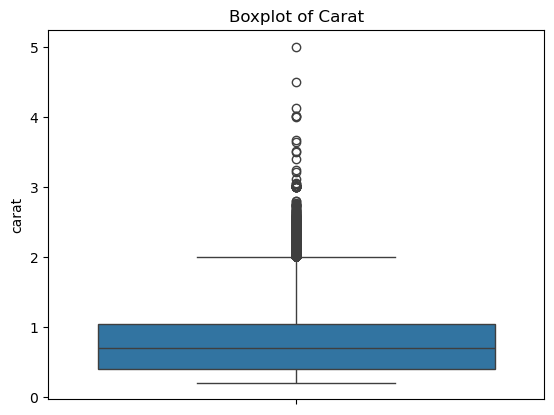

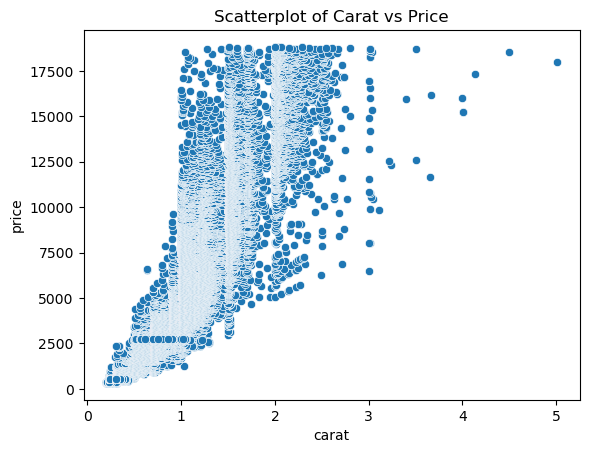

In [8]:
# Boxplot to visualize outliers in the 'carat' column
sns.boxplot(data['carat'])
plt.title('Boxplot of Carat')
plt.show()

# Scatterplot to visualize the relationship between 'carat' and 'price'
sns.scatterplot(x='carat', y='price', data=data)
plt.title('Scatterplot of Carat vs Price')
plt.show()

## Handling Outliers Using Z-Score
The Z-score method identifies outliers as data points that are a certain number of standard deviations away from the mean.

In [9]:
# Calculate Z-scores for 'carat' and 'price'
from scipy.stats import zscore

data['zscore_carat'] = zscore(data['carat'])
data['zscore_price'] = zscore(data['price'])

# Filter out outliers based on Z-score (threshold = 3)
filtered_data_zscore = data[(data['zscore_carat'].abs() <= 3) & (data['zscore_price'].abs() <= 3)]
filtered_data_zscore.head()  # Display the filtered dataset

,carat,price,zscore_carat,zscore_price
0,0.23,326,-1.198168,-0.904095
1,0.21,326,-1.240361,-0.904095
2,0.23,327,-1.198168,-0.903844
3,0.29,334,-1.071587,-0.902090
4,0.31,335,-1.029394,-0.901839


## Handling Outliers Using the IQR Method
The IQR method identifies outliers as data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [10]:
# Calculate the Interquartile Range (IQR) for 'carat'
Q1 = data['carat'].quantile(0.25)  # First quartile
Q3 = data['carat'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers based on the IQR method
filtered_data_iqr = data[(data['carat'] >= lower_bound) & (data['carat'] <= upper_bound)]
filtered_data_iqr.head()  # Display the filtered dataset

,carat,price,zscore_carat,zscore_price
0,0.23,326,-1.198168,-0.904095
1,0.21,326,-1.240361,-0.904095
2,0.23,327,-1.198168,-0.903844
3,0.29,334,-1.071587,-0.902090
4,0.31,335,-1.029394,-0.901839


## Conclusion
We have demonstrated how to detect and handle outliers using visualization, Z-score, and the IQR method. You can choose the method that best suits your dataset and analysis requirements.